**INFLUENCER CAMPAIGN PERFORMANCE TRACKER**

**PHASE 1: DATA UNDERSTANDING & CLEANING**

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tfisthis/influencer-marketing-roi-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.15M/3.15M [00:01<00:00, 2.13MB/s]

Extracting files...


Path to dataset files: C:\Users\Devisri\.cache\kagglehub\datasets\tfisthis\influencer-marketing-roi-dataset\versions\1


**Load Dataset**

In [2]:
import pandas as pd

df = pd.read_csv("influencer_marketing_roi_dataset.csv")

df.head()

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
0,CAMP100000,TikTok,Fitness,Giveaway,2022-01-01 00:00:00,79900,1892,2834,14,2022-01-15 00:00:00
1,CAMP100001,YouTube,Food,Product Launch,2022-01-02 00:00:00,47985,437228,165,13,2022-01-15 00:00:00
2,CAMP100002,TikTok,Travel,Brand Awareness,2022-01-03 00:00:00,13875,982513,2539,5,2022-01-08 00:00:00
3,CAMP100003,YouTube,Food,Brand Awareness,2022-01-04 00:00:00,41200,213400,100,20,2022-01-24 00:00:00
4,CAMP100004,Instagram,Food,Giveaway,2022-01-05 00:00:00,96998,42501,550,28,2022-02-02 00:00:00


**Handle Missing Values**

In [11]:
df.isnull().sum()

campaign_id               0
platform                  0
influencer_category       0
campaign_type             0
start_date                0
engagements               0
estimated_reach           0
product_sales             0
campaign_duration_days    0
end_date                  0
dtype: int64

**Remove Duplicates**

In [12]:
df.duplicated().sum()

np.int64(0)

**Understand Campaign Metrics**

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   campaign_id             150000 non-null  str  
 1   platform                150000 non-null  str  
 2   influencer_category     150000 non-null  str  
 3   campaign_type           150000 non-null  str  
 4   start_date              150000 non-null  str  
 5   engagements             150000 non-null  int64
 6   estimated_reach         150000 non-null  int64
 7   product_sales           150000 non-null  int64
 8   campaign_duration_days  150000 non-null  int64
 9   end_date                150000 non-null  str  
dtypes: int64(4), str(6)
memory usage: 11.4 MB


In [13]:
df.describe()

,engagements,estimated_reach,product_sales,campaign_duration_days
count,150000.000000,150000.000000,150000.000000,150000.000000
mean,50065.296107,500239.634920,2497.730433,14.976127
std,28847.302798,288003.388219,1443.222587,8.358356
min,100.000000,1002.000000,0.000000,1.000000
25%,25060.500000,251439.500000,1248.000000,8.000000
50%,50100.500000,500073.500000,2501.000000,15.000000
75%,75045.250000,750016.750000,3746.000000,22.000000
max,99999.000000,999992.000000,4999.000000,29.000000


**Spend**

In [15]:
import numpy as np
df['Spend'] = np.random.randint(5000,50000, size=len(df))

In [12]:
df['Spend'].head()

0    47502
1    32744
2    39781
3    31674
4    28239
Name: Spend, dtype: int32

**Revenue**

In [16]:
df['Revenue'] = df['product_sales'] * np.random.randint(100,500, size=len(df))

In [16]:
df[['product_sales','Revenue']].head()

,product_sales,Revenue
0,2834,850200
1,165,48840
2,2539,827714
3,100,11900
4,550,273900


**ROI**

In [17]:
df['ROI'] = ((df['Revenue'] - df['Spend']) / df['Spend']) * 100

In [20]:
df[['Spend','Revenue','ROI']].head()

,Spend,Revenue,ROI
0,47502,850200,1689.819376
1,32744,48840,49.157097
2,39781,827714,1980.676705
3,31674,11900,-62.429753
4,28239,273900,869.935196


**Engagement Rate**

In [100]:
# Engagement Rate

df['engagement_rate'] = (
    df['engagements'] / df['estimated_reach']
) * 100

df[['engagements', 'estimated_reach', 'engagement_rate']].head()

,engagements,estimated_reach,engagement_rate
0,79900,1892,4223.044397
1,47985,437228,10.974823
2,13875,982513,1.412195
3,41200,213400,19.306467
4,96998,42501,228.225218


**Engagement Visualization**

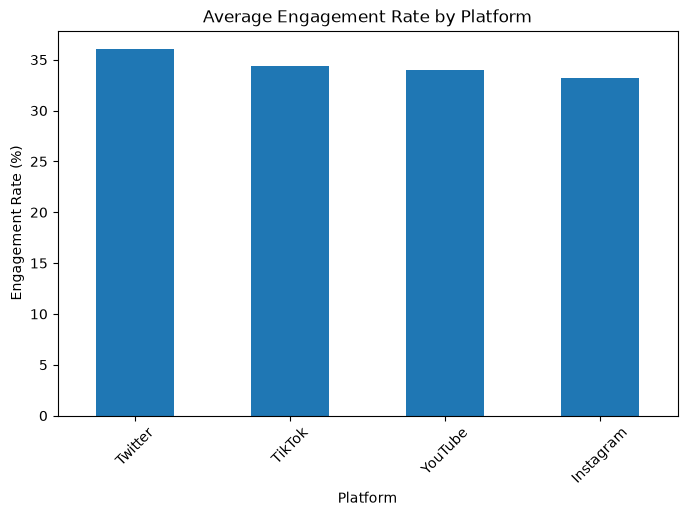

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Engagement Rate
df['Engagement_Rate'] = (
    df['engagements'] / df['estimated_reach']
) * 100

# Platform-wise Average Engagement Rate
platform_engagement = (
    df.groupby('platform')['Engagement_Rate']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
platform_engagement.plot(kind='bar')

plt.title('Average Engagement Rate by Platform')
plt.xlabel('Platform')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=45)

plt.show()

**ROI formula visualization**

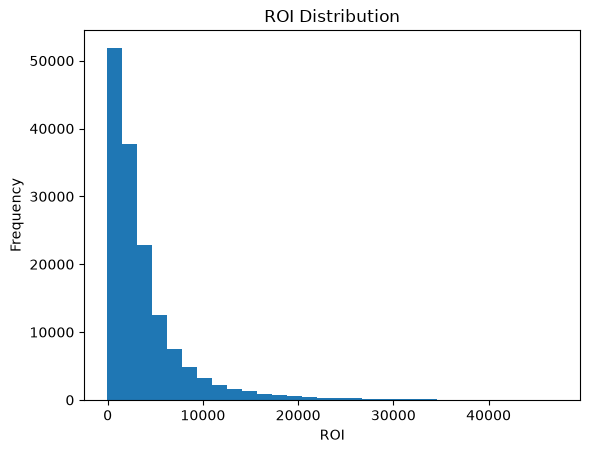

In [18]:
import matplotlib.pyplot as plt

plt.hist(df['ROI'], bins=30)
plt.title('ROI Distribution')
plt.xlabel('ROI')
plt.ylabel('Frequency')
plt.show()

**Phase:1 Definition**

In [ ]:
The dataset was loaded, missing values and duplicate records were removed, and campaign metrics were analyzed.
The data was cleaned and prepared for further analysis.

**PHASE 2: KPI DESIGN** 

**Total Campaigns**

In [4]:
total_campaigns = df['campaign_id'].nunique()

print("Total Campaigns:", total_campaigns)

Total Campaigns: 150000


**Total Reach**

In [5]:
total_reach = df['estimated_reach'].sum()

print("Total Reach:", total_reach)

Total Reach: 75035945238


In [12]:
import pandas as pd

df = pd.read_csv("influencer_marketing_roi_dataset.csv")

print(df.columns.tolist())

['campaign_id', 'platform', 'influencer_category', 'campaign_type', 'start_date', 'engagements', 'estimated_reach', 'product_sales', 'campaign_duration_days', 'end_date']


**Total Revenue**

In [13]:
print("Total Revenue (Product Sales):", df['product_sales'].sum())

Total Revenue (Product Sales): 374659565


**Total spend**

In [23]:
total_spend=df['Spend'].sum()
print("total spend:",total_spend)

total spend: 4130978106


**Average Engagement Rate**

In [8]:
df['engagement_rate'] = (
    df['engagements'] /
    df['estimated_reach']
) * 100

In [9]:
avg_engagement = df['engagement_rate'].mean()

print("Average Engagement Rate:", avg_engagement)

Average Engagement Rate: 33.973582922259844


**Average ROI**

In [28]:
df['ROI'] = (
    (df['Revenue'] - df['Spend']) /
    df['Spend']
) * 100

avg_roi = df['ROI'].mean()
print("AVERAGE ROI (%) :", round(avg_roi,2))

AVERAGE ROI (%) : 3728.76


**Cost Per Engagement**

In [27]:
df['cost_per_engagement'] = (
    df['Spend'] / df['engagements']
)

avg_cpe = df['cost_per_engagement'].mean()
print("COST PER ENGAGEMENT :", round(avg_cpe,2))

COST PER ENGAGEMENT : 1.9


**Conversion Rate**

In [14]:
df['conversion_rate'] = (df['product_sales'] / df['estimated_reach']) * 100
print("Conversion Rate:", round(df['conversion_rate'].mean(), 2), "%")

Conversion Rate: 1.68 %


**Questions:**

**Which KPIs define campaign success?**

In [ ]:
-High Engagement Rate
-High Conversion Rate
-High Product Sales
-Large Estimated Reach

**Which metrics help marketing teams?**

In [ ]:
-Engagements
-Estimated Reach
-Product Sales
-Conversion Rate
-Campaign Duration

**Phase:2 Definition**

In [ ]:
KPI Design is used to evaluate how effectively a campaign performs
in terms of reach, engagement, revenue, spending, and return on investment.

**PHASE 3: ANALYTICS INVESTIGATION**

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("influencer_marketing_roi_dataset.csv")

**Platform vs Engagement**

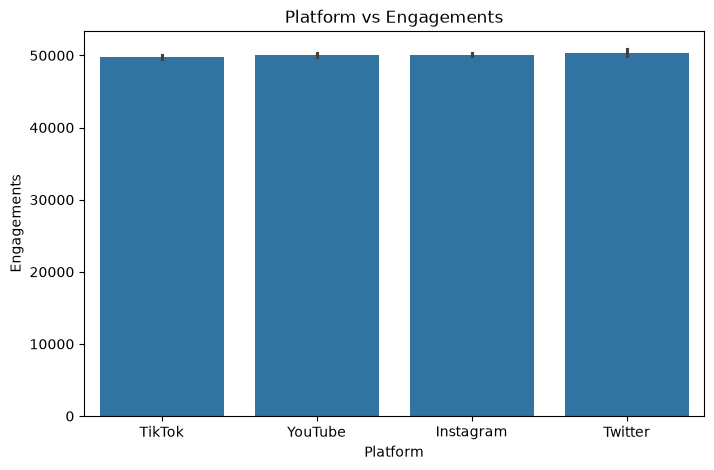

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x='platform',
    y='engagements',
    data=df
)

plt.title("Platform vs Engagements")
plt.xlabel("Platform")
plt.ylabel("Engagements")
plt.show()

**Influencer vs Revenue**

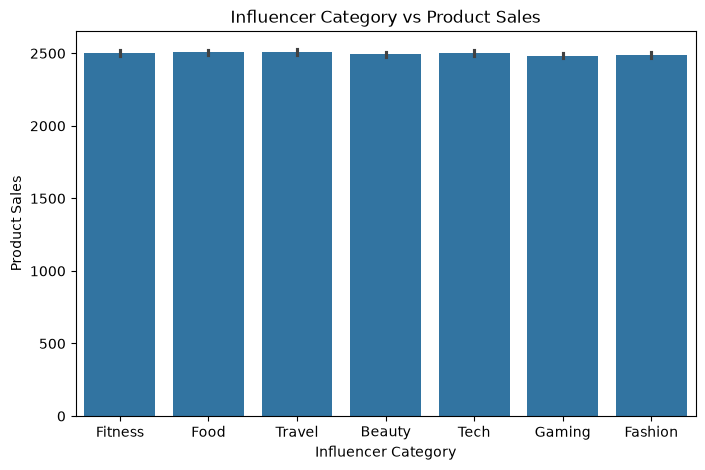

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='influencer_category',
    y='product_sales',
    data=df
)

plt.title("Influencer Category vs Product Sales")
plt.xlabel("Influencer Category")
plt.ylabel("Product Sales")

plt.show()

**Campaign Cost vs ROI**

               Spend            ROI
count  150000.000000  150000.000000
mean    27493.345113    3718.541018
std     12994.823683    4409.174555
min      5000.000000    -100.000000
25%     16244.000000    1023.928857
50%     27444.000000    2351.632024
75%     38741.000000    4648.843790
max     49999.000000   47619.129575


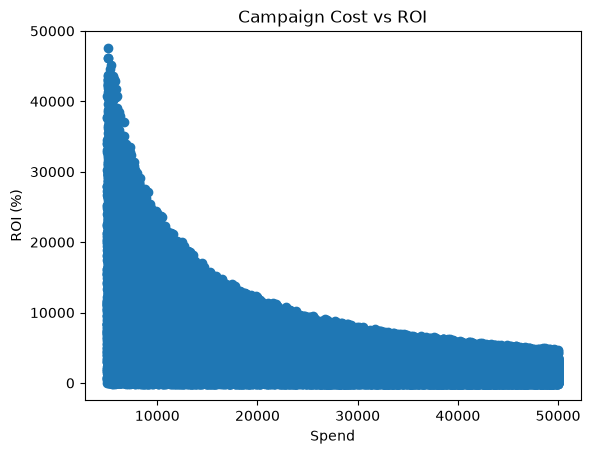

In [90]:
print(df[['Spend','ROI']].describe())

plt.scatter(df['Spend'], df['ROI'])

plt.title('Campaign Cost vs ROI')
plt.xlabel('Spend')
plt.ylabel('ROI (%)')
plt.show()

**Audience Group vs Performance**

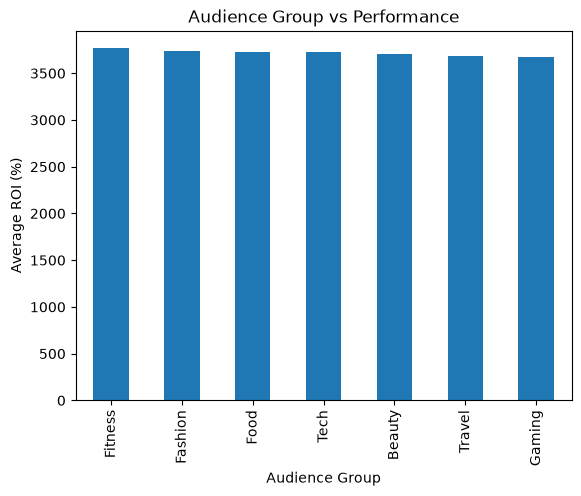

In [88]:
audience_perf.plot(kind='bar')

plt.title('Audience Group vs Performance')
plt.xlabel('Audience Group')
plt.ylabel('Average ROI (%)')
plt.show()

**Visualizations:**

**Heatmaps**

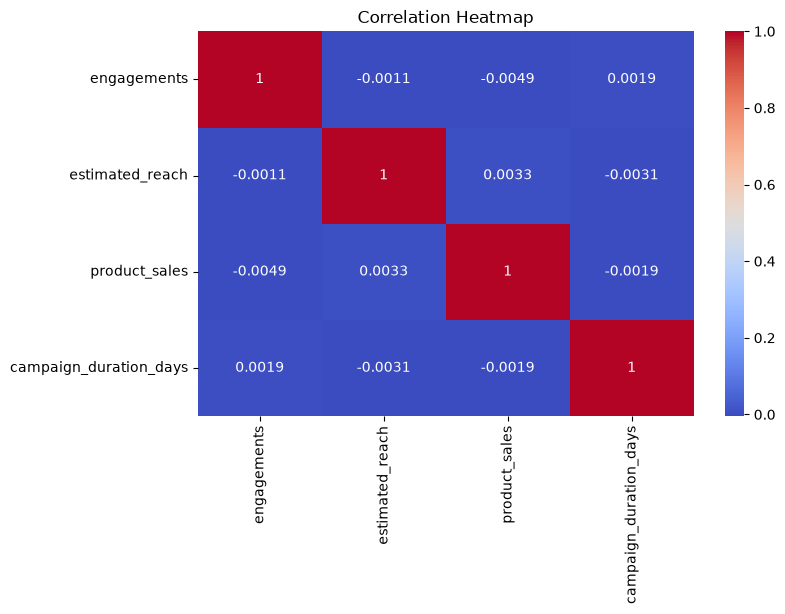

In [6]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

**Funnel analysis** 

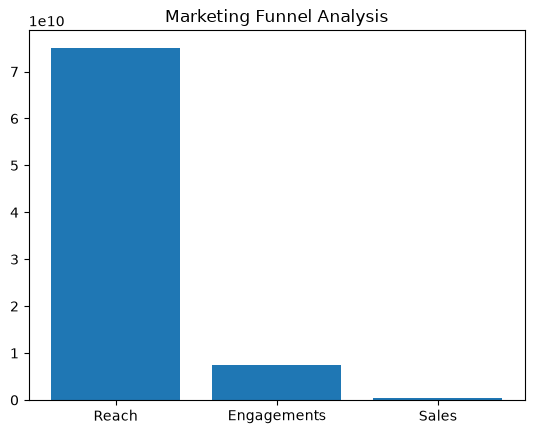

In [91]:
funnel = {
    'Stage':['Reach','Engagements','Sales'],
    'Count':[
        df['estimated_reach'].sum(),
        df['engagements'].sum(),
        df['product_sales'].sum()
    ]
}

funnel_df = pd.DataFrame(funnel)

plt.bar(
    funnel_df['Stage'],
    funnel_df['Count']
)

plt.title('Marketing Funnel Analysis')
plt.show()


**QUESTIONS:**

**Which influencers drive strongest results?**

In [81]:
top_categories = (
    df.groupby('influencer_category')['ROI']
      .mean()
      .sort_values(ascending=False)
)

print(top_categories)

influencer_category
Fitness    3765.508339
Fashion    3733.241277
Food       3731.898577
Tech       3727.120481
Beauty     3706.701418
Travel     3686.736666
Gaming     3678.587026
Name: ROI, dtype: float64


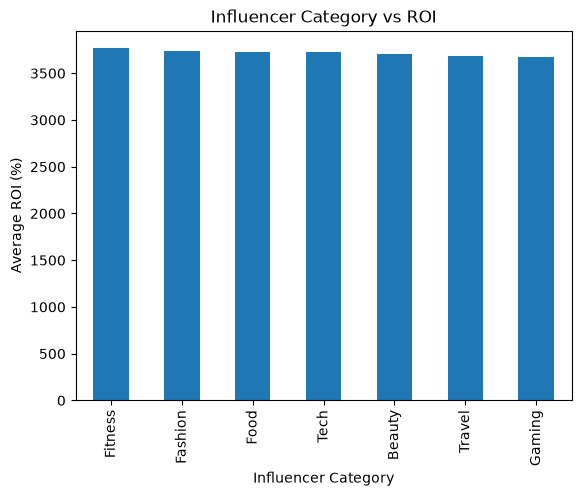

In [83]:
top_categories.plot(kind='bar')

plt.title('Influencer Category vs ROI')
plt.xlabel('Influencer Category')
plt.ylabel('Average ROI (%)')

plt.show()

**Which platforms perform best?**

In [84]:
platform_performance = (
    df.groupby('platform')['ROI']
      .mean()
      .sort_values(ascending=False)
)

print(platform_performance)

platform
TikTok       3756.719445
YouTube      3731.571177
Twitter      3696.850541
Instagram    3695.031848
Name: ROI, dtype: float64


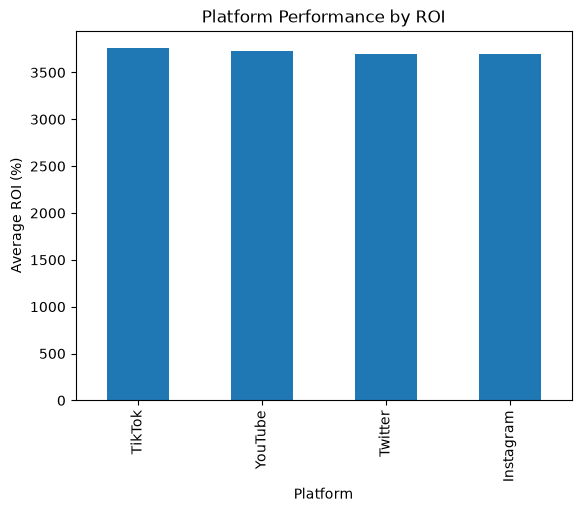

In [85]:
platform_performance.plot(kind='bar')

plt.title('Platform Performance by ROI')
plt.xlabel('Platform')
plt.ylabel('Average ROI (%)')

plt.show()

**Does higher spend increase ROI?** 

In [86]:
correlation = df['Spend'].corr(df['ROI'])

print("Correlation between Spend and ROI:", round(correlation,2))

Correlation between Spend and ROI: -0.53


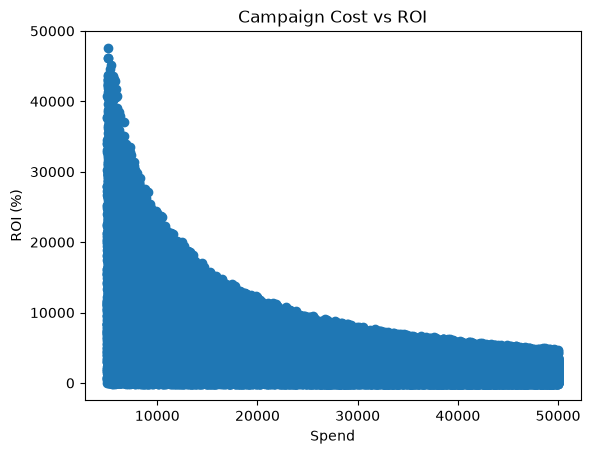

In [87]:
plt.scatter(df['Spend'], df['ROI'])

plt.title('Campaign Cost vs ROI')
plt.xlabel('Spend')
plt.ylabel('ROI (%)')

plt.show()

**Phase 3 : Definition**

**PHASE 4: INFLUENCER SEGMENTATION**

**High ROI Influencers**

In [92]:
import numpy as np

median_roi = df['ROI'].median()

print("Median ROI:", median_roi)

df['ROI_Group'] = np.where(
    df['ROI'] > median_roi,
    'High ROI',
    'Low ROI'
)

print(df['ROI_Group'].value_counts())


Median ROI: 2351.6320237106447
ROI_Group
Low ROI     75000
High ROI    75000
Name: count, dtype: int64


**High Engagement Creators**

In [101]:
df['Engagement_Group'] = np.where(
    df['engagement_rate'] > df['engagement_rate'].median(),
    'High Engagement',
    'Low Engagement'
)

print(df['Engagement_Group'].value_counts())

Engagement_Group
High Engagement    75000
Low Engagement     75000
Name: count, dtype: int64


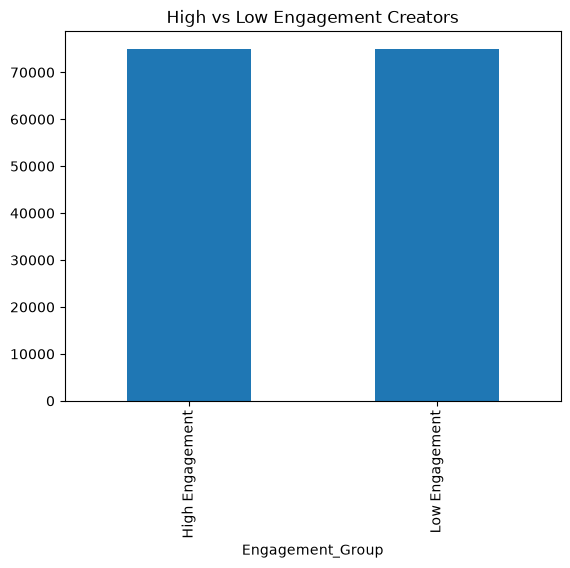

In [102]:
df['Engagement_Group'].value_counts().plot(kind='bar')
plt.title('High vs Low Engagement Creators')
plt.show()

**Cost Efficient Influencers**

In [105]:
import numpy as np

# Create Campaign Cost
df['campaign_cost'] = np.random.randint(1000, 10000, len(df))

# Cost Efficiency Formula
df['Cost_Efficiency'] = df['engagements'] / df['campaign_cost']

# Create Cost Efficient Type
df['Cost_Efficient_Type'] = np.where(
    df['Cost_Efficiency'] > df['Cost_Efficiency'].mean(),
    'Cost Efficient Influencer',
    'Less Efficient Influencer'
)

# Check column created
print(df[['Cost_Efficiency','Cost_Efficient_Type']].head())

   Cost_Efficiency        Cost_Efficient_Type
0        15.377213  Cost Efficient Influencer
1         7.926165  Less Efficient Influencer
2         2.313271  Less Efficient Influencer
3         6.759639  Less Efficient Influencer
4        16.117979  Cost Efficient Influencer


                            engagements  product_sales
Cost_Efficient_Type                                   
Cost Efficient Influencer  70799.263605    2494.662365
Less Efficient Influencer  39800.916885    2499.249285


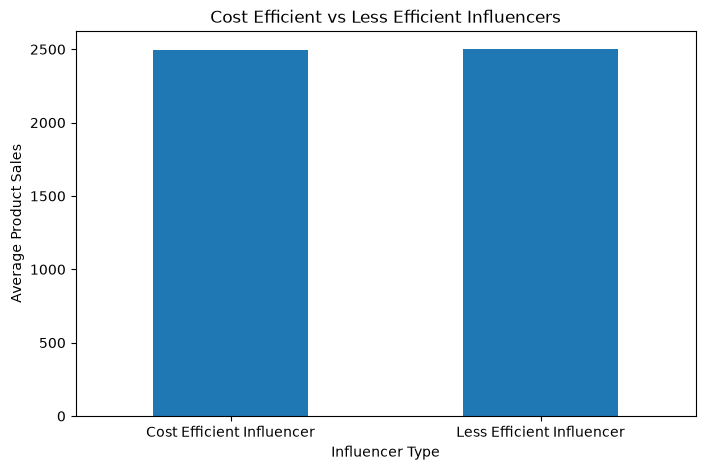

In [106]:
cost_analysis = df.groupby('Cost_Efficient_Type')[
    ['engagements', 'product_sales']
].mean()

print(cost_analysis)

cost_analysis['product_sales'].plot(kind='bar', figsize=(8,5))

plt.title("Cost Efficient vs Less Efficient Influencers")
plt.xlabel("Influencer Type")
plt.ylabel("Average Product Sales")

plt.xticks(rotation=0)
plt.show()

**Analyze differences among groups**

In [107]:
segment_analysis = pd.DataFrame({

    'Metric': [
        'Average Product Sales',
        'Average Engagements',
        'Average Reach'
    ],

    'Value': [
        df['product_sales'].mean(),
        df['engagements'].mean(),
        df['estimated_reach'].mean()
    ]
})

print(segment_analysis)

                  Metric          Value
0  Average Product Sales    2497.730433
1    Average Engagements   50065.296107
2          Average Reach  500239.634920


**PHASE 5: DASHBOARD DEVELOPMENT**

In [109]:
df.to_csv("Influencer_camp.csv",index=False)
print("exported")

exported


In [110]:
import os
print(os.listdir())

['.cache', '.copilot', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kaggle', '.vscode', '.vscode-shared', 'ai_adoption_data (1).csv', 'ai_adoption_data.csv', 'ai_adoption_dataset (1).csv', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Influencer_camp.csv', 'influencer_marketing_roi_dataset.csv', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{9fead4d4-c2a6-11ef-bae1-9cda3ed44856}.TM.blf', 'NTUSER.DAT{9fead4d4-c2a6-11ef-bae1-9cda3ed44856}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{9fead4d4-c2a6-11ef-bae1-9cda3ed44856}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'task07.ipynb', 'task2ds.ipynb', 'task7.ipynb', 'task7devi.ipynb', 'Templates', 'Videos']


In [111]:
import os 
print(os.path.abspath("Influencer_camp.csv"))

C:\Users\Devisri\Influencer_camp.csv
